# Assignment 3

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model](https://open.spotify.com/track/4R3AU2pjv8ge2siX1fVbZs?si=b2712f32da0e4358) or a simple [linear regression model](https://scikit-learn.org/stable/modules/linear_model.html)
        - An advanced regressor of your choice (e.g., Random Forest, Neural Network, etc.)

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn import set_config
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer, RobustScaler
import shap
import pickle
import os

set_config(display='diagram')

# Load dataset
file_path = '../../05_src/data/fires/forestfires.csv'

columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area'
]

fires_dt = pd.read_csv(file_path, header=0, names=columns)

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


## Data Prep and Cleaning

### Convert non-numeric columns to appropriate type
### Handling of missing values

In [2]:
fires_dt['month'] = fires_dt['month'].astype('category')
fires_dt['day'] = fires_dt['day'].astype('category')
fires_dt.ffill(inplace=True)

# Get X and Y

Create the features data frame and target data.

In [3]:
# Separate features and target
features = fires_dt.drop(columns=['area'])
target = fires_dt['area']

# Ensure all categorical features are converted to numeric
features = pd.get_dummies(features, columns=['month', 'day'], drop_first=True)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Define numerical features
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [4]:
scalers = {
    'std': StandardScaler(),
    'robust': RobustScaler(),
    'minmax': MinMaxScaler()
}

scalers

{'std': StandardScaler(), 'robust': RobustScaler(), 'minmax': MinMaxScaler()}

In [5]:

# Create preprocessing pipelines
preproc1 = ColumnTransformer(
    transformers=[
        ('num_std', scalers['std'], numerical_cols)
    ],
    remainder='passthrough'
)

preproc1

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_std', StandardScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain'])])

### Preproc 2

Create preproc2 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [6]:
preproc2 = ColumnTransformer(
    transformers=[
        ('num_std', Pipeline([
            ('scaler', scalers['std']),
            ('non_linear', PowerTransformer())
        ]), numerical_cols)
    ],
    remainder='passthrough'
)

preproc2

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_std',
                                 Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('non_linear',
                                                  PowerTransformer())]),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain'])])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [7]:
# Define the baseline and advanced regressors
baseline_regressor = LinearRegression()
baseline_regressor


LinearRegression()

In [8]:
advanced_regressor = RandomForestRegressor()
advanced_regressor

RandomForestRegressor()

In [9]:
# Pipeline A: preproc1 + baseline
# Pipeline B: preproc2 + baseline
# Pipeline C: preproc1 + advanced
# Pipeline D: preproc2 + advanced
pipelines = {
    'pipeline_A': Pipeline(steps=[('preprocessing', preproc1), ('regressor', baseline_regressor)]),
    'pipeline_B': Pipeline(steps=[('preprocessing', preproc2), ('regressor', baseline_regressor)]),
    'pipeline_C': Pipeline(steps=[('preprocessing', preproc1), ('regressor', advanced_regressor)]),
    'pipeline_D': Pipeline(steps=[('preprocessing', preproc2), ('regressor', advanced_regressor)])
}

In [10]:
#pipeline_A = Pipeline(steps=[('preprocessing', preproc1), ('regressor', baseline_regressor)])
#pipeline_B = Pipeline(steps=[('preprocessing', preproc2), ('regressor', baseline_regressor)])
#pipeline_C = Pipeline(steps=[('preprocessing', preproc1), ('regressor', advanced_regressor)])
#pipeline_D = Pipeline(steps=[('preprocessing', preproc2), ('regressor', advanced_regressor)])


In [11]:
pipelines.items()

dict_items([('pipeline_A', Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_std', StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain'])])),
                ('regressor', LinearRegression())])), ('pipeline_B', Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_std',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('non_linear',
                                                                   PowerTransformer())]),
    

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [12]:
# Define parameter grids for GridSearchCV
param_grids = {
    'pipeline_A': {'regressor__fit_intercept': [True, False]},
    'pipeline_B': {'regressor__fit_intercept': [True, False]},
    'pipeline_C': {'regressor__n_estimators': [100, 200, 300], 'regressor__max_depth': [None, 10, 20]},
    'pipeline_D': {'regressor__n_estimators': [100, 200, 300], 'regressor__max_depth': [None, 10, 20]}
}

In [13]:
# Perform GridSearchCV for each pipeline
grid_searches = {}
for name, pipeline in pipelines.items():
    grid_search = GridSearchCV(pipeline, param_grids[name], cv=5, scoring='neg_mean_squared_error', error_score='raise')
    grid_search.fit(X_train, y_train)
    grid_searches[name] = grid_search
    print(f'Best parameters for {name}: {grid_search.best_params_}')
    print(f'Best cross-validation score for {name}: {grid_search.best_score_}')

Best parameters for pipeline_A: {'regressor__fit_intercept': True}
Best cross-validation score for pipeline_A: -2234.7630218685363
Best parameters for pipeline_B: {'regressor__fit_intercept': False}
Best cross-validation score for pipeline_B: -2160.42218652499
Best parameters for pipeline_C: {'regressor__max_depth': 10, 'regressor__n_estimators': 300}
Best cross-validation score for pipeline_C: -2728.2470386972273
Best parameters for pipeline_D: {'regressor__max_depth': None, 'regressor__n_estimators': 100}
Best cross-validation score for pipeline_D: -2734.8223938085907


# Evaluate

+ Which model has the best performance?

In [14]:
# Collecting the best scores for each pipeline
scores = {name: grid_search.best_score_ for name, grid_search in grid_searches.items()}
scores


{'pipeline_A': -2234.7630218685363,
 'pipeline_B': -2160.42218652499,
 'pipeline_C': -2728.2470386972273,
 'pipeline_D': -2734.8223938085907}

In [15]:

# Identify the best performing pipeline
best_pipeline_name = max(scores, key=scores.get)
best_pipeline_score = scores[best_pipeline_name]

print(f'The best performing pipeline is {best_pipeline_name} with a score of {best_pipeline_score}')

# Get the best model from the best performing pipeline
best_model = grid_searches[best_pipeline_name].best_estimator_

The best performing pipeline is pipeline_B with a score of -2160.42218652499


# Export

+ Save the best performing model to a pickle file.

In [16]:
# Ensure the directory exists for saving the model
output_dir = '../../06_output/data/Fires'
os.makedirs(output_dir, exist_ok=True)

# Save the best model to a pickle file
with open(os.path.join(output_dir, 'best_model.pkl'), 'wb') as file:
    pickle.dump(best_model, file)

print('The best model has been saved to best_model.pkl')

The best model has been saved to best_model.pkl


# Explain (Questions)

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [17]:
try:
    import shap
    print("SHAP is installed successfully.")
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    print("SHAP is not installed.")

SHAP is installed successfully.
SHAP version: 0.42.1


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


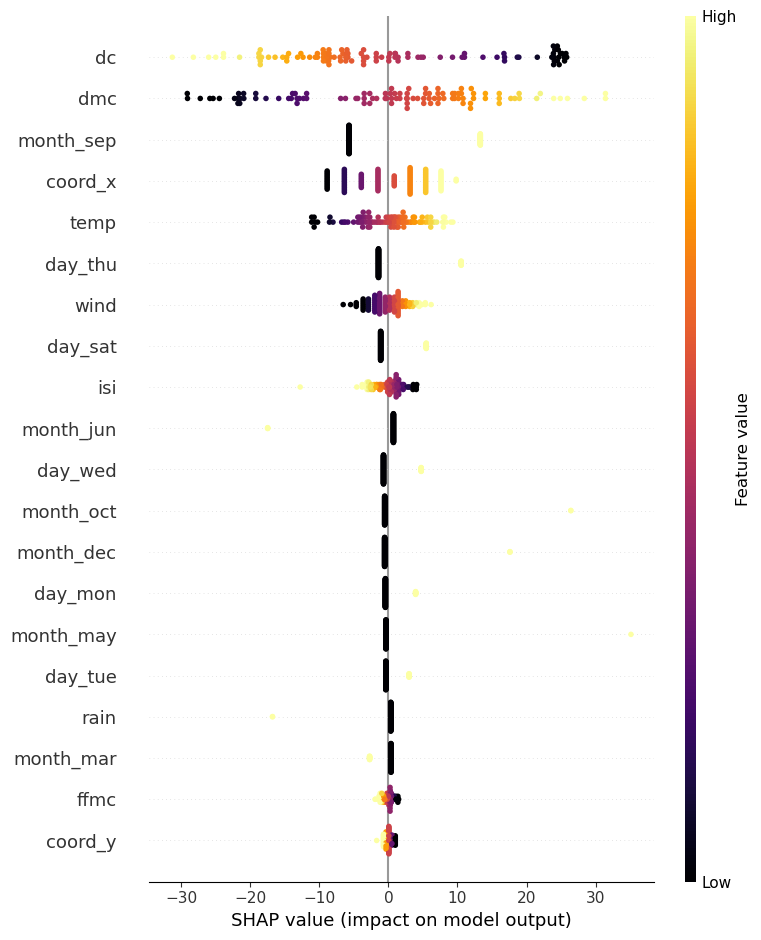

In [18]:
from matplotlib.pyplot import inferno


X_test_transformed = best_model.named_steps['preprocessing'].transform(X_test)

# Initialize the SHAP explainer with feature names
explainer = shap.Explainer(best_model.named_steps['regressor'], X_test_transformed, feature_names=X_test.columns)

# Compute SHAP values for the entire test set
shap_values_all = explainer(X_test_transformed)

# Summary plot to show feature importance
shap.summary_plot(shap_values_all, X_test_transformed, feature_names=X_test.columns,cmap="inferno")

# Explain (Answers)

- The chart highlights the significant role of the Drought Code (DC) index 'dc' and the Duff Moisture Code (DMC) index 'dmc' in predicting the size of forest fires. High values of these features tend to increase the expected fire size. However, it's important to note that other factors like the 'month' and 'temperature' also play a role, albeit to a lesser extent.

- In terms of colours, bright colours means high value of the feature whereas dark colours means low value of the feature. 

- Factors with more dots on the right side generally increase the predicted fire size. In comparison, factors with more dots on the left side typically decrease the predicted fire size.

- Features like Fine Fuel Moisture Code (FFMC) 'ffmc' and 'coord_y' have the least impact on predictions. These features have low SHAP values, indicating they don't contribute much to the model's predictions. Removing them can simplify the model without significantly affecting performance.

- To test that these features enhance the model performance, I will:
    - Remove the least influential features and retrain the model.
    - Compare performance metrics between the original and new models without the features.
    - Perform cross-validation to ensure the model's performance is consistent.
    - Generate SHAP plots for the new model to confirm that the remaining features contribute effectively.


## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 07/07/2024`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/FredyLRincon/scaling_to_production/pull/4`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [X] Created a branch with the correct naming convention.
- [X] Ensured that the repository is public.
- [X] Reviewed the PR description guidelines and adhered to them.
- [X] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.